Kernel ek mathematical function hai jo non-linear data ko higher dimensions me map karta hai, jisse SVM us data ko linear boundary se separate kar sake.
A kernel is a mathematical function that enables SVM to classify non-linear data by implicitly mapping it into a higher-dimensional space, where it becomes linearly separable.

Why is it needed?
When data cannot be separated by a straight line, a kernel helps SVM find a suitable decision boundary without explicitly transforming the data.

Common Kernels
Linear → Best for linearly separable data.
Polynomial → Captures polynomial relationships.
RBF (Radial Basis Function) → Best for complex non-linear data (most commonly used).
Sigmoid → Similar to a neural network activation function; used less frequently.

Gamma controls the influence of a single training data point. A small gamma gives a smoother decision boundary, while a large gamma creates a more complex boundary and increases the risk of overfitting.
#Epsilon (ε) is the error tolerance in SVR. Errors inside the epsilon tube are ignored, and only errors outside the tube are penalized.
#eps is only used for svr

This dataset is artificially created to demonstrate a non-linear classification problem. It helps us clearly understand why a Linear SVM fails and why a Kernel (RBF) SVM is needed. In real-world projects, we generally use real datasets rather than creating synthetic ones

np.vstack() → Vertical Stack → Places arrays one above the other (stacks them row-wise).
np.hstack() → Horizontal Stack → Places arrays side by side (stacks them column-wise for 2D arrays,

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from IPython.display import display
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

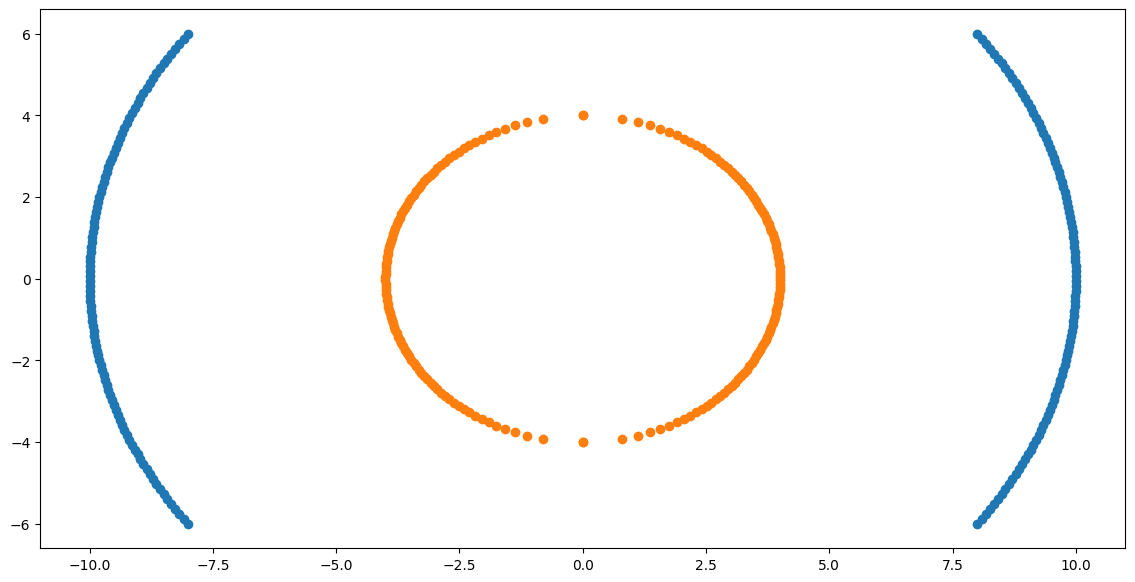

In [2]:
#The aim of this code is to generate a non-linear circular dataset (two concentric circles) to demonstrate why kernel-based SVM is needed instead of a linear SVM.
x=np.linspace(-6,6,100)
y=np.sqrt(10**2-x**2)
x=np.hstack([x,-x])
y=np.hstack([y,-y])

x1=np.linspace(-4,4,100)
y1=np.sqrt(4**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

plt.figure(figsize=(14,7))
plt.scatter(y,x)
plt.scatter(y1,x1)
plt.show()

In [3]:
df1=pd.DataFrame(np.vstack([y,x]).T ,columns=['X1','X2']) # .T (transpose) converts rows into columns and columns into rows, so that each row represents one data point (x, y).
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T ,columns=['X1','X2'])
df2['Y']=1
df=pd.concat([df1,df2],ignore_index=True)
display(df)

df1=df.copy(deep=True)# by default it is deep copy
df1['X1square']=df1['X1']**2
df1['X2square']=df1['X2']**2
df1['X1X2']=df['X1']*df1['X2']
display(df1.head(5))
df1=df1.dropna()
# Deriving x and y value
x=df1[['X1square','X2square','X1X2']]
y=df1['Y']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
fig=px.scatter_3d(df1,x='X1square',y='X2square',z='X1X2',color='Y')
fig.show()

,X1,X2,Y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
395,-1.575239,-3.676768,1
396,-1.371359,-3.757576,1
397,-1.125526,-3.838384,1
398,-0.799959,-3.919192,1


,X1,X2,Y,X1square,X2square,X1X2
0,8.000000,-6.000000,0,64.000000,36.000000,-48.000000
1,8.089490,-5.878788,0,65.439853,34.560147,-47.556397
2,8.176205,-5.757576,0,66.850321,33.149679,-47.075117
3,8.260230,-5.636364,0,68.231405,31.768595,-46.557662
4,8.341649,-5.515152,0,69.583104,30.416896,-46.005457


In [4]:
# you can change kernel = rbf,sigmoid,poly
cls=SVC(kernel='linear') #  we have created polynomial data
cls.fit(x_train,y_train)
y_cls_pred=cls.predict(x_test)
acc_svc=accuracy_score(y_test,y_cls_pred)
display(acc_svc)

1.0

In [5]:
# applying kernel with hyperparameter tuning
param_grid={
    'C':[0.1,0.5,1,1.5,2,5,10],
    'kernel':['rbf','linear','poly','sigmoid'],
    'gamma':[0.1,0.2,0.5,1,1.5,2,3,4,5]
}
model=GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5,verbose=2)
model.fit(x_train,y_train)
y_kernel_pred=model.predict(x_test)
acc_kernel=accuracy_score(y_test,y_kernel_pred)
display(acc_kernel)

Fitting 5 folds for each of 252 candidates, totalling 1260 fits
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ......................C=0.1, gamma=0

[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.5, kernel=poly; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.5, kernel=poly; total time=   0.0s
[CV] END ...................

1.0

In [6]:
display(model.best_params_)
display(model.best_estimator_)

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}

,C,0.1
,kernel,'linear'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False
